# Faster Than Expected: Causal Effect of Early Delivery on Customer Satisfaction
**Methodology:** PSM (KNN + caliper) → Double Machine Learning (CausalForestDML, econml) → Opportunity Ranking  
**Dataset:** [Olist Brazilian E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Treatment:** Order delivered ≥ 3 days before estimated date (`early_delivery = 1`)  
**Outcome:** Customer review score (1–5)

In [1]:
import os, gc, warnings
from copy import deepcopy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import (
    roc_auc_score, mean_absolute_error,
    mean_squared_error, r2_score
)

from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from econml.dml import CausalForestDML

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

D:\Causal_Effect_Olist_BR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Constants ───────────────────────────────────────────────────────────────

def categorize_product(name_en: str) -> str:
    if pd.isna(name_en):
        return "other"
    n = str(name_en).lower()
    if any(k in n for k in ["computer", "electron", "telephon", "tablet", "audio", "console", " pc"]):
        return "electronics"
    if any(k in n for k in ["furniture", "bed", "bath", "house", "kitchen", "garden", "home", "decor", "cookware"]):
        return "home_decor"
    if any(k in n for k in ["fashion", "shoe", "bag", "watch", "luggage", "cloth"]):
        return "fashion"
    if any(k in n for k in ["health", "beauty", "perfum", "baby", "diaper", "hygiene"]):
        return "health_beauty"
    if any(k in n for k in ["sport", "leisure", "outdoor"]):
        return "sports"
    if any(k in n for k in ["toy", "book", "art", "music", "dvd", "stationer"]):
        return "media_toys"
    if any(k in n for k in ["food", "drink", "grocer", "beverage"]):
        return "food"
    if any(k in n for k in ["auto"]):
        return "automotive"
    if any(k in n for k in ["tool", "construct", "industri", "agro"]):
        return "tools_industry"
    if any(k in n for k in ["office", "cool stuff", "gift", "Christmas"]):
        return "office_gifts"
    if "pet" in n:
        return "pet"
    return "other"


STATE_TO_REGION = {
    "AC": "N",  "AP": "N",  "AM": "N",  "PA": "N",
    "RO": "N",  "RR": "N",  "TO": "N",
    "AL": "NE", "BA": "NE", "CE": "NE", "MA": "NE",
    "PB": "NE", "PE": "NE", "PI": "NE", "RN": "NE", "SE": "NE",
    "DF": "CO", "GO": "CO", "MS": "CO", "MT": "CO",
    "ES": "SE_BR", "MG": "SE_BR", "RJ": "SE_BR", "SP": "SE_BR",
    "PR": "S",  "RS": "S",  "SC": "S",
}

In [3]:
def load_and_engineer_features(data_dir: str) -> pd.DataFrame:
    """
    Loads and joins the Olist tables, computes features, and defines treatment.

    Treatment: early_delivery = 1 when the order arrived >= 3 days before
    the estimated delivery date (positive surprise to the customer).
    Outcome: review_score (1–5).

    Parameters
    ----------
    data_dir : str
        Path to the directory containing the unzipped Olist CSV files.

    Returns
    -------
    pd.DataFrame
        Order-level DataFrame ready for PSM.
    """
    orders   = pd.read_csv(f"{data_dir}/olist_orders_dataset.csv")
    items    = pd.read_csv(f"{data_dir}/olist_order_items_dataset.csv")
    reviews  = pd.read_csv(f"{data_dir}/olist_order_reviews_dataset.csv")
    products = pd.read_csv(f"{data_dir}/olist_products_dataset.csv")
    sellers  = pd.read_csv(f"{data_dir}/olist_sellers_dataset.csv")
    customers = pd.read_csv(f"{data_dir}/olist_customers_dataset.csv")
    payments = pd.read_csv(f"{data_dir}/olist_order_payments_dataset.csv")
    cat_tr   = pd.read_csv(f"{data_dir}/product_category_name_translation.csv")

    # ── Date parsing ────────────────────────────────────────────────────────
    ts_cols = ["order_purchase_timestamp", "order_delivered_customer_date",
               "order_estimated_delivery_date"]
    for col in ts_cols:
        orders[col] = pd.to_datetime(orders[col])

    # ── Filter: delivered orders only ───────────────────────────────────────
    orders = orders[
        (orders["order_status"] == "delivered") &
        orders["order_delivered_customer_date"].notna() &
        orders["order_estimated_delivery_date"].notna()
    ].copy()

    # ── Treatment variable ──────────────────────────────────────────────────
    orders["days_early"] = (
        orders["order_estimated_delivery_date"] - orders["order_delivered_customer_date"]
    ).dt.days
    orders["early_delivery"] = (orders["days_early"] >= 3).astype(int)

    # ── Temporal features ───────────────────────────────────────────────────
    orders["order_month"] = orders["order_purchase_timestamp"].dt.month
    orders["days_to_estimated"] = (
        orders["order_estimated_delivery_date"] - orders["order_purchase_timestamp"]
    ).dt.days

    # ── Aggregate items → one row per order ────────────────────────────────
    items_agg = (
        items.groupby("order_id")
        .agg(price=("price", "sum"),
             freight_value=("freight_value", "sum"),
             seller_id=("seller_id", "first"),
             product_id=("product_id", "first"),
             n_items=("order_item_id", "count"))
        .reset_index()
    )

    # ── First review per order ──────────────────────────────────────────────
    reviews_agg = (
        reviews.sort_values("review_creation_date")
        .groupby("order_id")[["review_score"]]
        .first()
        .reset_index()
    )

    # ── Primary payment per order ───────────────────────────────────────────
    pay_agg = (
        payments.sort_values(["order_id", "payment_sequential"])
        .groupby("order_id")
        .first()
        .reset_index()[["order_id", "payment_type", "payment_installments"]]
    )

    # ── Product category (English) ──────────────────────────────────────────
    products = products.merge(cat_tr, on="product_category_name", how="left")

    # ── Join ────────────────────────────────────────────────────────────────
    df = (
        orders[["order_id", "customer_id", "order_purchase_timestamp",
                "days_early", "early_delivery", "order_month", "days_to_estimated"]]
        .merge(items_agg, on="order_id", how="inner")
        .merge(reviews_agg, on="order_id", how="inner")
        .merge(products[["product_id", "product_category_name_english",
                         "product_weight_g", "product_length_cm",
                         "product_height_cm", "product_width_cm"]],
               on="product_id", how="left")
        .merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
        .merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
        .merge(pay_agg, on="order_id", how="left")
    )

    # ── Derived numeric features ────────────────────────────────────────────
    df["freight_pct_of_price"] = (df["freight_value"] / df["price"].clip(lower=0.01)).clip(0, 5)
    df["product_volume_cm3"]   = df["product_length_cm"] * df["product_height_cm"] * df["product_width_cm"]

    for col in ["product_weight_g", "product_volume_cm3"]:
        df[col] = df[col].fillna(df[col].median())

    df["is_same_state"] = (df["seller_state"] == df["customer_state"]).astype(int)
    df["payment_installments"] = df["payment_installments"].fillna(1).clip(1, 12)

    # ── Seasonal dummies ────────────────────────────────────────────────────
    df["quarter_Q1"] = df["order_month"].isin([1, 2, 3]).astype(float)
    df["quarter_Q2"] = df["order_month"].isin([4, 5, 6]).astype(float)
    df["quarter_Q3"] = df["order_month"].isin([7, 8, 9]).astype(float)

    # ── Categorical features ────────────────────────────────────────────────
    df["category_group"]  = df["product_category_name_english"].apply(categorize_product)
    df["seller_region"]   = df["seller_state"].map(STATE_TO_REGION).fillna("SE_BR")
    df["customer_region"] = df["customer_state"].map(STATE_TO_REGION).fillna("SE_BR")
    df["price_tier"]      = pd.qcut(df["price"], q=3,
                                    labels=["budget", "mid", "premium"]).astype(str)
    df["payment_type"]    = df["payment_type"].fillna("credit_card")

    # ── Seller aggregate features (historical stats) ─────────────────────────
    # Note: computed on the full dataset as a proxy; for strict correctness
    # use a leave-one-out expanding window (see README — Limitations).
    seller_stats = (
        df.groupby("seller_id")
        .agg(seller_avg_review=("review_score", "mean"),
             seller_total_orders=("order_id", "count"),
             seller_early_rate=("early_delivery", "mean"))
        .reset_index()
    )
    first_sale = (
        df.groupby("seller_id")["order_purchase_timestamp"]
        .min().rename("seller_first_sale").reset_index()
    )
    df = df.merge(seller_stats, on="seller_id", how="left")
    df = df.merge(first_sale, on="seller_id", how="left")
    df["seller_experience_months"] = (
        (df["order_purchase_timestamp"] - df["seller_first_sale"]).dt.days / 30
    ).clip(lower=0)

    # ── Final eligibility filters ───────────────────────────────────────────
    df = df[
        (df["price"] > 1) &
        (df["product_weight_g"] > 0) &
        (df["days_to_estimated"].between(1, 60)) &
        (df["review_score"].notna())
    ].reset_index(drop=True)

    print(f"Dataset: {len(df):,} orders  |  "
          f"Treatment rate: {df['early_delivery'].mean():.1%}  |  "
          f"Avg review: {df['review_score'].mean():.3f}")
    return df

In [4]:
def apply_psm(df: pd.DataFrame,
              list_features_numeric: list,
              list_features_categorical: list,
              n_matches: int,
              seed: int) -> pd.DataFrame:
    """
    Propensity Score Matching — KNN multidimensional + absolute caliper.

    Simplified relative to production (no 3-seed multi-start, no 50:1 subsampling)
    because the Olist treatment ratio (~22%) does not require extreme imbalance
    correction. The caliper threshold follows the Cochrane standard: 0.2 * SD(PS).

    Parameters
    ----------
    n_matches : int
        Number of control matches per treated unit (1:n matching).
    """
    df = df.reset_index(drop=True)
    df_t = df[df["early_delivery"] == 1].reset_index(drop=True)
    df_c = df[df["early_delivery"] == 0].reset_index(drop=True)
    n_t, n_c = len(df_t), len(df_c)
    print(f"Pre-PSM  →  Treated: {n_t:,}  |  Controls: {n_c:,}  |  Ratio 1:{n_c/n_t:.1f}")

    # ── Standardize numeric features ────────────────────────────────────────
    scaler = StandardScaler()
    X_num_t = scaler.fit_transform(df_t[list_features_numeric].astype(float))
    X_num_c = scaler.transform(df_c[list_features_numeric].astype(float))

    # ── OHE categorical features ────────────────────────────────────────────
    df_cat_all = pd.concat(
        [df_t[list_features_categorical], df_c[list_features_categorical]],
        ignore_index=True
    )
    ohe_all = pd.get_dummies(df_cat_all, drop_first=True).astype(float).values
    X_t = np.hstack([X_num_t, ohe_all[:n_t]])
    X_c = np.hstack([X_num_c, ohe_all[n_t:]])
    X_all = np.vstack([X_t, X_c])
    y_all = np.array([1] * n_t + [0] * n_c)

    # ── Propensity score for caliper ────────────────────────────────────────
    ps_model = LogisticRegression(
        solver="lbfgs", max_iter=500,
        class_weight="balanced", random_state=seed
    )
    ps_model.fit(X_all, y_all)
    ps_all = ps_model.predict_proba(X_all)[:, 1]
    ps_t   = ps_all[:n_t]
    ps_c   = ps_all[n_t:]
    caliper = 0.2 * ps_all.std()

    # ── KNN matching ────────────────────────────────────────────────────────
    knn = NearestNeighbors(n_neighbors=n_matches, metric="euclidean", algorithm="ball_tree")
    knn.fit(X_c)
    _, nn_idx = knn.kneighbors(X_t)

    treat_keep, ctrl_rows = [], []
    used_ctrl = set()

    for i in range(n_t):
        good = [
            j for j in nn_idx[i]
            if j not in used_ctrl and abs(ps_t[i] - ps_c[j]) <= caliper
        ][:n_matches]
        if good:
            used_ctrl.update(good)
            treat_keep.append(i)
            ctrl_rows.extend(good)

    df_t_psm = df_t.iloc[treat_keep].copy()
    df_c_psm = df_c.iloc[ctrl_rows].copy()
    df_t_psm["flag"] = "treatment"
    df_c_psm["flag"] = "control"

    df_psm = pd.concat([df_t_psm, df_c_psm], ignore_index=True)

    n_t_final = (df_psm["flag"] == "treatment").sum()
    n_c_final = (df_psm["flag"] == "control").sum()
    n_dropped = n_t - n_t_final

    # ── Balance check ───────────────────────────────────────────────────────
    vol_t = df_psm.loc[df_psm["flag"] == "treatment", "seller_avg_review"].astype(float)
    vol_c = df_psm.loc[df_psm["flag"] == "control",   "seller_avg_review"].astype(float)
    pooled_std = np.sqrt((vol_t.std()**2 + vol_c.std()**2) / 2)
    cohens_d   = (vol_t.mean() - vol_c.mean()) / pooled_std if pooled_std > 0 else 0

    print(f"Post-PSM →  Treated: {n_t_final:,}  |  Controls: {n_c_final:,}  |  "
          f"Dropped (caliper): {n_dropped:,} ({n_dropped/n_t:.1%})")
    print(f"Balance (seller_avg_review): Cohen's d = {cohens_d:.3f}  "
          f"{'✓ OK' if abs(cohens_d) < 0.25 else '⚠ ALTO'}")
    return df_psm

In [5]:
def preprocess_dataframe(df_psm: pd.DataFrame,
                         list_features_numeric: list,
                         list_features_categorical: list,
                         test_frac: float = 0.2):
    """
    Temporal 80/20 train-test split + ColumnTransformer (StandardScaler + OHE).
    Adds quarterly seasonality dummies.
    Returns transformed DataFrames that retain ID and target columns.
    """
    df_psm = df_psm.sort_values("order_purchase_timestamp").reset_index(drop=True)

    # Quarterly dummies (already in df but ensure they exist)
    df_psm["quarter_Q1"] = df_psm["order_month"].isin([1, 2, 3]).astype(float)
    df_psm["quarter_Q2"] = df_psm["order_month"].isin([4, 5, 6]).astype(float)
    df_psm["quarter_Q3"] = df_psm["order_month"].isin([7, 8, 9]).astype(float)

    n_train = int(len(df_psm) * (1 - test_frac))
    df_train = df_psm.iloc[:n_train].copy()
    df_test  = df_psm.iloc[n_train:].copy()

    print(f"Train: {len(df_train):,}  |  Test: {len(df_test):,}")
    print(f"Train period: {df_train['order_purchase_timestamp'].min().date()} → "
          f"{df_train['order_purchase_timestamp'].max().date()}")
    print(f"Test  period: {df_test['order_purchase_timestamp'].min().date()} → "
          f"{df_test['order_purchase_timestamp'].max().date()}")

    list_temporal = ["quarter_Q1", "quarter_Q2", "quarter_Q3"]
    all_numeric   = list_features_numeric + list_temporal

    ct = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary",
                                  sparse_output=False), list_features_categorical),
            ("num", StandardScaler(), all_numeric),
        ],
        verbose_feature_names_out=False
    ).fit(df_train)

    passthrough_cols = ["order_id", "seller_id", "review_score",
                        "early_delivery", "category_group", "seller_region"]

    def _transform(df):
        arr = ct.transform(df)
        if hasattr(arr, "toarray"):
            arr = arr.toarray()
        out = pd.DataFrame(arr, columns=ct.get_feature_names_out(), index=df.index)
        for col in passthrough_cols:
            out[col] = df[col].values
        return out

    return _transform(df_train), _transform(df_test)


def split_for_dml(df_train_t, df_test_t, dict_clip):
    """
    Extracts X (features), y (outcome), t (treatment) arrays for CausalForestDML.
    Clips review_score to valid scale [1, 5].
    """
    reserved = {"order_id", "seller_id", "review_score",
                 "early_delivery", "category_group", "seller_region"}
    feature_cols = [c for c in df_train_t.columns if c not in reserved]

    for df in [df_train_t, df_test_t]:
        df["review_score"] = df["review_score"].clip(
            dict_clip["clip_lower"], dict_clip["clip_upper"]
        )

    def _split(df):
        ids = df[["order_id", "seller_id"]].copy()
        X   = df[feature_cols].astype(float)
        y   = df[["review_score"]].astype(float)
        t   = df[["early_delivery"]].astype(float)
        return ids, X, y, t

    id_train, X_train, y_train, t_train = _split(df_train_t)
    id_test,  X_test,  y_test,  t_test  = _split(df_test_t)

    print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  "
          f"Features: {len(feature_cols)}")
    return id_train, X_train, y_train, t_train, id_test, X_test, y_test, t_test

In [6]:
def objective_optuna(trial, params_search, X_train, y_train, seed):
    """Generic Optuna objective — supports both regressor and classifier search spaces."""
    params_block = deepcopy(params_search)
    if "model_regressor" in params_block:
        model   = params_block["model_regressor"]
        scoring = "neg_mean_squared_error"
    else:
        model   = params_block["model_classifier"]
        scoring = "roc_auc"

    model.set_params(**params_block["params"](trial))
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    scores = cross_val_score(model, X=X_train, y=y_train.values.ravel(),
                             cv=kf, scoring=scoring, n_jobs=-1)
    return np.mean(scores)


def create_y_t_model(params_search, X_train, y_train, seed, n_trials=30):
    """Runs Optuna for one model block and returns the fitted best model."""
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed)
    )
    study.optimize(
        lambda trial: objective_optuna(trial, params_search, X_train, y_train, seed),
        n_trials=n_trials, timeout=600, show_progress_bar=False
    )
    best_params = study.best_params
    is_regressor = "model_regressor" in params_search

    if is_regressor:
        model = deepcopy(params_search["model_regressor"])
        score = -study.best_value   # convert neg_MSE to positive MSE
    else:
        model = deepcopy(params_search["model_classifier"])
        score = study.best_value    # AUC, higher is better

    model.set_params(**best_params)
    model.fit(X_train, y_train.values.ravel())
    return model, best_params, score


def create_and_select_best_models(ps_lgbm_y, ps_xgb_y, ps_lgbm_t, ps_xgb_t,
                                  X_train, y_train, t_train, seed):
    """Trains LGBM and XGB for Y (regressor) and T (classifier); picks the best."""
    print("Tuning Y model (outcome regressor)…")
    m_ly, p_ly, s_ly = create_y_t_model(ps_lgbm_y, X_train, y_train, seed)
    m_xy, p_xy, s_xy = create_y_t_model(ps_xgb_y,  X_train, y_train, seed)

    print("Tuning T model (treatment classifier)…")
    m_lt, p_lt, s_lt = create_y_t_model(ps_lgbm_t, X_train, t_train, seed)
    m_xt, p_xt, s_xt = create_y_t_model(ps_xgb_t,  X_train, t_train, seed)

    # Best Y = lower MSE
    if s_ly <= s_xy:
        model_y, params_y, score_y, name_y = m_ly, p_ly, s_ly, "lgbm"
    else:
        model_y, params_y, score_y, name_y = m_xy, p_xy, s_xy, "xgb"

    # Best T = higher AUC
    if s_lt >= s_xt:
        model_t, params_t, score_t, name_t = m_lt, p_lt, s_lt, "lgbm"
    else:
        model_t, params_t, score_t, name_t = m_xt, p_xt, s_xt, "xgb"

    print(f"  Y → {name_y.upper()}  (OOF MSE: {score_y:.4f})")
    print(f"  T → {name_t.upper()}  (OOF AUC: {score_t:.4f})")
    return model_y, params_y, score_y, name_y, model_t, params_t, score_t, name_t

In [7]:
def create_dml_model(params_dml, X_train, y_train, t_train,
                     model_y, model_t, seed, groups=None):
    """Instantiates and fits the CausalForestDML model."""
    print("Training CausalForestDML…")
    model_dml = CausalForestDML(
        model_y=model_y,
        model_t=model_t,
        random_state=seed,
        cv=5,
        discrete_treatment=True,
        **params_dml["params"]
    )
    fit_kwargs = dict(
        Y=y_train.values.ravel(),
        T=t_train.values.ravel(),
        X=X_train
    )
    if groups is not None:
        fit_kwargs["groups"] = groups
    model_dml.fit(**fit_kwargs)
    return model_dml, params_dml


def obtain_metrics_intermediate(X, y_true, t_true, model_y, model_t, suffix):
    """R2 for Y model and AUC for T model."""
    y_arr, t_arr = np.array(y_true).ravel(), np.array(t_true).ravel()
    y_pred   = model_y.predict(X)
    t_proba  = model_t.predict_proba(X)[:, 1]
    return {
        f"MAE_{suffix}":  mean_absolute_error(y_arr, y_pred),
        f"RMSE_{suffix}": np.sqrt(mean_squared_error(y_arr, y_pred)),
        f"R2_{suffix}":   r2_score(y_arr, y_pred),
        f"AUC_{suffix}":  roc_auc_score(t_arr, t_proba),
    }


def obtain_metrics_dml(model_dml):
    """ATE and ATT (T=0 and T=1) with 95% confidence intervals."""
    def _ate(m):
        try: return m.ate__inference()
        except AttributeError: return m.ate_inference()

    def _att(m, T):
        try: return m.att__inference(T=T)
        except AttributeError: return m.att_inference(T=T)

    ate_df  = _ate(model_dml).summary_frame(alpha=0.05)
    att1_df = _att(model_dml, T=1).summary_frame(alpha=0.05)
    att0_df = _att(model_dml, T=0).summary_frame(alpha=0.05)

    return {
        "ATE":          ate_df["point_estimate"].values[0],
        "ATE_ci_lower": ate_df["ci_lower"].values[0],
        "ATE_ci_upper": ate_df["ci_upper"].values[0],
        "ATT_1":        att1_df["point_estimate"].values[0],
        "ATT_1_ci_lower": att1_df["ci_lower"].values[0],
        "ATT_1_ci_upper": att1_df["ci_upper"].values[0],
        "ATT_0":        att0_df["point_estimate"].values[0],
        "ATT_0_ci_lower": att0_df["ci_lower"].values[0],
        "ATT_0_ci_upper": att0_df["ci_upper"].values[0],
    }

In [8]:
# ── Configuration ────────────────────────────────────────────────────────────

DATA_DIR = "data/"   # path to unzipped Olist dataset
seed     = 42
n_matches = 3        # 1:3 PSM ratio

list_features_numeric = [
    "price", "freight_value", "freight_pct_of_price",
    "days_to_estimated", "product_weight_g", "product_volume_cm3",
    "n_items", "payment_installments",
    "seller_avg_review", "seller_total_orders",
    "seller_early_rate", "seller_experience_months",
    "is_same_state",
]

list_features_categorical = [
    "category_group", "seller_region", "customer_region",
    "price_tier", "payment_type",
]

# PSM uses fewer features to avoid over-restricting the caliper
list_features_psm_numeric = [
    "price", "freight_pct_of_price", "days_to_estimated",
    "product_weight_g", "seller_avg_review", "seller_total_orders",
    "is_same_state",
]
list_features_psm_categorical = [
    "category_group", "seller_region", "price_tier",
]

dict_clip = {"clip_lower": 1.0, "clip_upper": 5.0}

# ── Optuna search spaces ──────────────────────────────────────────────────────

params_search_lgbm_y = {
    "model_regressor": LGBMRegressor(random_state=seed, verbosity=-1, n_jobs=-1),
    "params": lambda trial: {
        "max_depth":         trial.suggest_int("max_depth", 3, 6),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 10, 50, step=5),
        "n_estimators":      trial.suggest_int("n_estimators", 50, 300, step=50),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.01, 5.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.01, 5.0, log=True),
    },
}

params_search_xgb_y = {
    "model_regressor": XGBRegressor(random_state=seed, verbosity=0,
                                     objective="reg:squarederror", n_jobs=-1),
    "params": lambda trial: {
        "max_depth":        trial.suggest_int("max_depth", 3, 6),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "n_estimators":     trial.suggest_int("n_estimators", 50, 300, step=50),
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 15),
    },
}

params_search_lgbm_t = {
    "model_classifier": LGBMClassifier(random_state=seed, verbosity=-1, n_jobs=-1),
    "params": lambda trial: {
        "max_depth":         trial.suggest_int("max_depth", 3, 6),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 10, 50, step=5),
        "n_estimators":      trial.suggest_int("n_estimators", 50, 300, step=50),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.01, 5.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.01, 5.0, log=True),
    },
}

params_search_xgb_t = {
    "model_classifier": XGBClassifier(random_state=seed, eval_metric="logloss",
                                       verbosity=0, n_jobs=-1),
    "params": lambda trial: {
        "max_depth":        trial.suggest_int("max_depth", 3, 6),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 0.5),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "n_estimators":     trial.suggest_int("n_estimators", 50, 300, step=50),
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 15),
    },
}

# CausalForestDML — tuned for ~50-80k observations
params_dml = {
    "dml_name": "causal_forest",
    "params": {
        "n_estimators":     200,
        "max_depth":        5,
        "min_samples_leaf": 0.01,   # ~1% of training set per leaf
        "max_features":     "sqrt",
    },
}

In [9]:
# ── Pipeline execution ────────────────────────────────────────────────────────

df_raw = load_and_engineer_features(DATA_DIR)

df_psm = apply_psm(
    df_raw,
    list_features_psm_numeric,
    list_features_psm_categorical,
    n_matches, seed
)

df_train_t, df_test_t = preprocess_dataframe(
    df_psm, list_features_numeric, list_features_categorical
)

id_train, X_train, y_train, t_train, \
id_test,  X_test,  y_test,  t_test = split_for_dml(
    df_train_t, df_test_t, dict_clip
)

Dataset: 95,604 orders  |  Treatment rate: 87.1%  |  Avg review: 4.157
Pre-PSM  →  Treated: 83,245  |  Controls: 12,359  |  Ratio 1:0.1
Post-PSM →  Treated: 8,037  |  Controls: 10,916  |  Dropped (caliper): 75,208 (90.3%)
Balance (seller_avg_review): Cohen's d = 0.010  ✓ OK
Train: 15,162  |  Test: 3,791
Train period: 2016-10-03 → 2018-05-18
Test  period: 2018-05-18 → 2018-08-29
X_train: (15162, 44)  |  X_test: (3791, 44)  |  Features: 44


In [10]:
# ── Model training ────────────────────────────────────────────────────────────

model_y, params_y, score_y, name_y, \
model_t, params_t, score_t, name_t = create_and_select_best_models(
    params_search_lgbm_y, params_search_xgb_y,
    params_search_lgbm_t, params_search_xgb_t,
    X_train, y_train, t_train, seed
)

# Groups = seller_id: orders from the same seller are correlated,
# so we cluster standard errors at the seller level for honest inference.
model_dml, params_dml = create_dml_model(
    params_dml, X_train, y_train, t_train,
    model_y, model_t, seed,
    groups=id_train["seller_id"].values
)

print(f"\nY model ({name_y.upper()})  OOF MSE: {score_y:.4f}")
print(f"T model ({name_t.upper()})  OOF AUC: {score_t:.4f}")
print(f"CausalForestDML params: {params_dml['params']}")

Tuning Y model (outcome regressor)…
Tuning T model (treatment classifier)…
  Y → XGB  (OOF MSE: 2.4334)
  T → XGB  (OOF AUC: 0.7008)
Training CausalForestDML…

Y model (XGB)  OOF MSE: 2.4334
T model (XGB)  OOF AUC: 0.7008
CausalForestDML params: {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 0.01, 'max_features': 'sqrt'}


In [11]:
# ── Evaluation ────────────────────────────────────────────────────────────────

dict_metrics_train = obtain_metrics_intermediate(
    X_train, y_train, t_train, model_y, model_t, "train"
)
dict_metrics_test = obtain_metrics_intermediate(
    X_test, y_test, t_test, model_y, model_t, "test"
)
dict_metrics_dml = obtain_metrics_dml(model_dml)
dict_metrics = {**dict_metrics_train, **dict_metrics_test, **dict_metrics_dml}

print(f"\n{'─'*55}")
print(f"  Y model ({name_y.upper()})  R2 train: {dict_metrics['R2_train']:.3f}  |  R2 test: {dict_metrics['R2_test']:.3f}")
print(f"  T model ({name_t.upper()})  AUC train: {dict_metrics['AUC_train']:.3f}  |  AUC test: {dict_metrics['AUC_test']:.3f}")
print(f"{'─'*55}")
print(f"  ATE: {dict_metrics['ATE']:.4f}  "
      f"(95% CI: [{dict_metrics['ATE_ci_lower']:.4f}, {dict_metrics['ATE_ci_upper']:.4f}])")
print(f"  ATT (treated): {dict_metrics['ATT_1']:.4f}  "
      f"(95% CI: [{dict_metrics['ATT_1_ci_lower']:.4f}, {dict_metrics['ATT_1_ci_upper']:.4f}])")
print(f"  ATT (control): {dict_metrics['ATT_0']:.4f}  "
      f"(95% CI: [{dict_metrics['ATT_0_ci_lower']:.4f}, {dict_metrics['ATT_0_ci_upper']:.4f}])")
print(f"{'─'*55}")


───────────────────────────────────────────────────────
  Y model (XGB)  R2 train: 0.133  |  R2 test: 0.049
  T model (XGB)  AUC train: 0.765  |  AUC test: 0.678
───────────────────────────────────────────────────────
  ATE: 1.2760  (95% CI: [1.2300, 1.3210])
  ATT (treated): 1.3260  (95% CI: [1.2470, 1.4040])
  ATT (control): 1.2430  (95% CI: [1.1880, 1.2990])
───────────────────────────────────────────────────────


In [12]:
# ── CATE distribution ──────────────────────────────────────────────────────────

effects = model_dml.effect(X_test)
lower, upper = model_dml.effect_interval(X_test, alpha=0.05)

df_effect = pd.DataFrame({
    "CATE":       effects.ravel(),
    "CATE_lower": lower.ravel(),
    "CATE_upper": upper.ravel(),
    "order_id":         id_test["order_id"].values,
    "seller_id":        id_test["seller_id"].values,
    "category_group":   df_test_t["category_group"].values,
    "seller_region":    df_test_t["seller_region"].values,
    "early_delivery":   t_test.values.ravel(),
    "review_score_obs": y_test.values.ravel(),
})

print(f"CATE statistics for {len(df_effect):,} test orders:\n")
print(df_effect["CATE"].describe().round(4))

fig = px.histogram(
    df_effect, x="CATE", nbins=60,
    title="Distribution of Individual Causal Effects (CATE) — Early Delivery on Review Score",
    labels={"CATE": "Estimated Effect on Review Score (points)"},
    color_discrete_sequence=["#2196F3"],
)
fig.add_vline(x=0, line_dash="dash", line_color="red",
              annotation_text="Zero (no effect)")
fig.add_vline(x=df_effect["CATE"].mean(), line_dash="dot", line_color="#4CAF50",
              annotation_text=f"ATE = {df_effect['CATE'].mean():.3f}")
fig.update_layout(template="plotly_white", height=420)
fig.show()

CATE statistics for 3,791 test orders:

count    3791.0000
mean        1.1254
std         0.1104
min         0.8924
25%         1.0343
50%         1.1262
75%         1.2023
max         1.3847
Name: CATE, dtype: float64


In [13]:
# ── GATES validation ───────────────────────────────────────────────────────────
# Group Average Treatment Effects — the CATE ranking should be monotone:
# quintiles predicted to have high CATE should show larger observed T-C gaps.

df_gates = df_effect.copy()
df_gates["cate_quintile"] = pd.qcut(
    df_gates["CATE"], q=5,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"]
)

gates_summary = (
    df_gates.groupby(["cate_quintile", "early_delivery"])
    .agg(avg_review_obs=("review_score_obs", "mean"),
         n=("order_id", "count"),
         cate_mean=("CATE", "mean"))
    .reset_index()
)

gates_pivot = gates_summary.pivot(
    index="cate_quintile", columns="early_delivery",
    values="avg_review_obs"
).rename(columns={0: "Control (obs)", 1: "Treated (obs)"})
gates_pivot["T-C gap (obs)"]     = gates_pivot["Treated (obs)"] - gates_pivot["Control (obs)"]
gates_pivot["CATE mean (pred.)"] = df_gates.groupby("cate_quintile")["CATE"].mean()

print("═══ GATES — Model Validation ═══")
print("T-C gap should increase from Q1 → Q5 if the model correctly ranks heterogeneity.\n")
print(gates_pivot.round(4).to_string())

diffs = gates_pivot["T-C gap (obs)"].values
corr  = np.corrcoef(gates_pivot["CATE mean (pred.)"], gates_pivot["T-C gap (obs)"])[0, 1]
is_monotone = all(diffs[i] <= diffs[i+1] for i in range(len(diffs)-1))

print(f"\nCorrelation (predicted CATE vs observed gap): {corr:.3f}")
print(f"Monotonic ranking: {'✓ Yes' if is_monotone else '✗ Not strictly — correlation matters more'}")
print(f"Interpretation: {'Model discriminates well.' if corr > 0.7 else 'Moderate discrimination — realistic for noisy review data.' if corr > 0.3 else 'Low discrimination — consider simplifying.'}")

═══ GATES — Model Validation ═══
T-C gap should increase from Q1 → Q5 if the model correctly ranks heterogeneity.

early_delivery  Control (obs)  Treated (obs)  T-C gap (obs)  CATE mean (pred.)
cate_quintile                                                                 
Q1 (lowest)            4.0895         4.4199         0.3304             0.9743
Q2                     4.0675         4.2041         0.1366             1.0552
Q3                     3.9227         4.3434         0.4208             1.1256
Q4                     3.4791         4.1924         0.7133             1.1846
Q5 (highest)           3.0214         4.3835         1.3621             1.2876

Correlation (predicted CATE vs observed gap): 0.888
Monotonic ranking: ✗ Not strictly — correlation matters more
Interpretation: Model discriminates well.


In [14]:
# ── Business charts — ATE/ATT and Feature Importance ─────────────────────────

# Chart 1: ATE / ATT with 95% CI
causal_df = pd.DataFrame({
    "Metric": ["ATE\n(Overall)", "ATT (T=1)\n(Early deliveries)", "ATT (T=0)\n(Late deliveries)"],
    "Est":    [dict_metrics["ATE"], dict_metrics["ATT_1"], dict_metrics["ATT_0"]],
    "Lo":     [dict_metrics["ATE_ci_lower"], dict_metrics["ATT_1_ci_lower"], dict_metrics["ATT_0_ci_lower"]],
    "Hi":     [dict_metrics["ATE_ci_upper"], dict_metrics["ATT_1_ci_upper"], dict_metrics["ATT_0_ci_upper"]],
})

fig = go.Figure()
fig.add_trace(go.Bar(
    x=causal_df["Metric"], y=causal_df["Est"],
    marker_color=["#1976D2", "#388E3C", "#F57C00"],
    text=[f"{v:.3f}" for v in causal_df["Est"]],
    textposition="outside", width=0.45,
))
fig.add_trace(go.Scatter(
    x=causal_df["Metric"], y=causal_df["Est"],
    error_y=dict(type="data", symmetric=False,
                 array=causal_df["Hi"] - causal_df["Est"],
                 arrayminus=causal_df["Est"] - causal_df["Lo"],
                 color="black", thickness=2, width=10),
    mode="markers", marker=dict(size=1), showlegend=False,
))
fig.add_hline(y=0, line_dash="dash", line_color="red", line_width=1)
fig.update_layout(
    title="Causal Effect of Early Delivery on Review Score (95% CI)",
    yaxis_title="Effect on Review Score (points)",
    template="plotly_white", height=450, showlegend=False,
)
fig.show()

# Chart 2: Feature importance
df_fi = (
    pd.DataFrame({"feature": X_train.columns,
                  "importance": model_dml.feature_importances_})
    .sort_values("importance", ascending=True)
    .tail(15)
)

fig2 = px.bar(
    df_fi, x="importance", y="feature", orientation="h",
    title="Top 15 Features Driving Heterogeneity in Early Delivery Effect",
    labels={"importance": "Relative Importance", "feature": ""},
    color="importance", color_continuous_scale="Blues",
)
fig2.update_layout(template="plotly_white", height=480, coloraxis_showscale=False)
fig2.show()

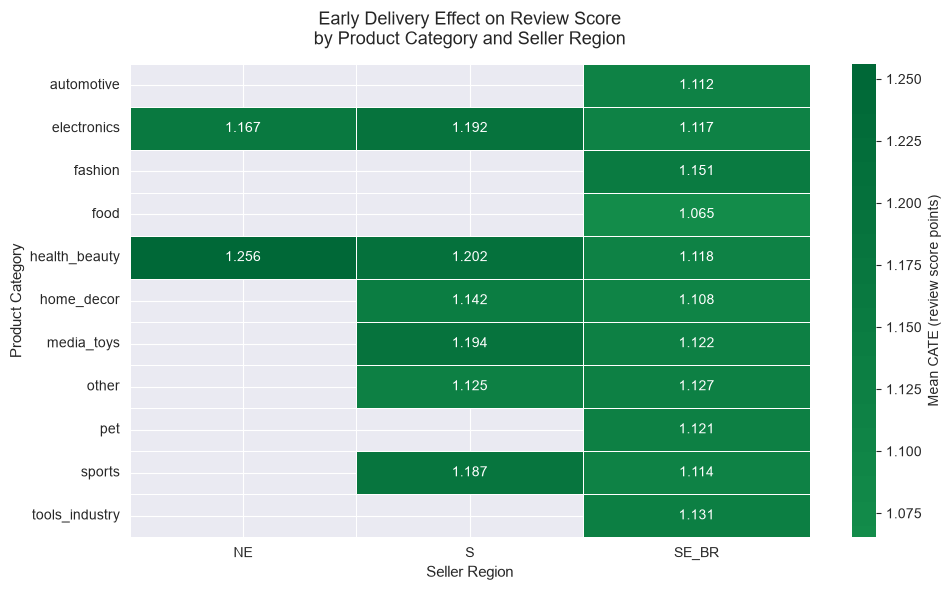

In [15]:
# ── Heatmap: Average CATE by Product Category x Seller Region ────────────────

heatmap_df = (
    df_effect.groupby(["category_group", "seller_region"])
    .agg(mean_cate=("CATE", "mean"), n=("order_id", "count"))
    .reset_index()
)

# Filter out sparse cells (< 20 orders)
heatmap_df = heatmap_df[heatmap_df["n"] >= 20]

pivot = heatmap_df.pivot(index="category_group", columns="seller_region", values="mean_cate")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot, annot=True, fmt=".3f", cmap="RdYlGn",
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Mean CATE (review score points)"},
)
ax.set_title("Early Delivery Effect on Review Score\nby Product Category and Seller Region",
             fontsize=13, pad=14)
ax.set_xlabel("Seller Region", fontsize=11)
ax.set_ylabel("Product Category", fontsize=11)
plt.tight_layout()
plt.show()

In [16]:
# ── Opportunity Ranking ───────────────────────────────────────────────────────
# Rank sellers WITHOUT early delivery habit by their CATE:
# these are the sellers who would gain the most from logistics improvement.

df_rank_full = df_effect.copy()

# IC width = precision weight
df_rank_full["ic_width"]         = df_rank_full["CATE_upper"] - df_rank_full["CATE_lower"]
df_rank_full["precision_weight"] = 1.0 / df_rank_full["ic_width"].clip(lower=0.01)

# Focus on "untreated" sellers (those whose orders tend not to arrive early)
# Proxy: seller_early_rate < 0.3
low_early_sellers = (
    df_psm[df_psm["seller_early_rate"] < 0.3]["seller_id"].unique()
)
df_rank = df_rank_full[df_rank_full["seller_id"].isin(low_early_sellers)].copy()

# Aggregate CATE per seller (precision-weighted average)
df_rank_agg = (
    df_rank.groupby(["seller_id", "category_group", "seller_region"])
    .apply(lambda g: pd.Series({
        "CATE_weighted": np.average(g["CATE"], weights=g["precision_weight"]),
        "CATE_lower":    g["CATE_lower"].mean(),
        "CATE_upper":    g["CATE_upper"].mean(),
        "n_orders":      len(g),
    }))
    .reset_index()
    .sort_values("CATE_weighted", ascending=False)
    .reset_index(drop=True)
)

df_rank_agg["rank"]              = range(1, len(df_rank_agg) + 1)
df_rank_agg["opportunity_score"] = (df_rank_agg["CATE_weighted"].rank(pct=True) * 100).round(0).astype(int)

output_path = "olist_delivery_cate_ranking.csv"
df_rank_agg.to_csv(output_path, index=False)
print(f"Ranking saved: {output_path}  |  {len(df_rank_agg):,} sellers ranked")
print(f"\nTop 10 sellers who would benefit most from faster logistics:\n")
print(df_rank_agg[["rank", "seller_id", "category_group", "seller_region",
                    "CATE_weighted", "opportunity_score", "n_orders"]].head(10).to_string(index=False))

Ranking saved: olist_delivery_cate_ranking.csv  |  29 sellers ranked

Top 10 sellers who would benefit most from faster logistics:

 rank                        seller_id category_group seller_region  CATE_weighted  opportunity_score  n_orders
    1 154bdf805377afea75a3bd158e9eab10  health_beauty         SE_BR       1.287685                100       1.0
    2 312ba1d77e9c332ef21f9598b7f64cd7  health_beauty         SE_BR       1.240654                 97       1.0
    3 edf3fabebcc20f7463cc9c53da932ea8     home_decor         SE_BR       1.214950                 93       1.0
    4 62de60d81c55c29d76a6bce418b31cef     automotive         SE_BR       1.199168                 90       1.0
    5 712efd3b68f9686dc856b84abd0f21ae  health_beauty             S       1.182443                 86       1.0
    6 9b1f656ca3060f8af17a50d8a024b533 tools_industry         SE_BR       1.170583                 83       1.0
    7 08cdbae123ff67ca4e36d9d641ce0119     home_decor         SE_BR       1.170398  

In [18]:
# ── Executive Summary ─────────────────────────────────────────────────────────

ate        = dict_metrics["ATE"]
att1       = dict_metrics["ATT_1"]
pct_pos    = (df_effect["CATE"] > 0).mean() * 100
n_sellers  = df_rank_agg["seller_id"].nunique()
top_cat    = (df_rank_agg.groupby("category_group")["CATE_weighted"].mean()
              .sort_values(ascending=False).index[0])
top_region = (df_rank_agg.groupby("seller_region")["CATE_weighted"].mean()
              .sort_values(ascending=False).index[0])

print(f"""
{'═'*65}
  EARLY DELIVERY EFFECT ON OLIST CUSTOMER SATISFACTION
  Double Machine Learning — Causal Analysis
{'═'*65}

  Causal Question
  ───────────────
  Does delivering an order >= 3 days ahead of the estimated date
  CAUSE a higher customer review score, after controlling for
  seller quality, product type, geography, and price?

  Core Results
  ────────────
  ATE  (average effect on any order)        : {ate:+.4f} review points
  ATT  (effect on actually early deliveries): {att1:+.4f} review points
  95% CI ATE: [{dict_metrics['ATE_ci_lower']:.4f}, {dict_metrics['ATE_ci_upper']:.4f}]

  Orders with positive CATE                 : {pct_pos:.1f}%

  Heterogeneity
  ─────────────
  Category with highest average CATE : {top_cat}
  Region with highest average CATE   : {top_region}
  Sellers with logistic opportunity  : {n_sellers:,}

  Model Quality
  ─────────────
  Y model ({name_y.upper()})  R2 test : {dict_metrics['R2_test']:.3f}
  T model ({name_t.upper()})  AUC test: {dict_metrics['AUC_test']:.3f}
  GATES correlation (pred. vs obs.)  : {corr:.3f}

  Business Takeaway
  ─────────────────
  An early delivery surprise adds, on average, {ate:.3f} review score
  points. The effect is heterogeneous — some categories ({top_cat})
  and regions ({top_region}) see disproportionately larger gains.
  The ranking in olist_delivery_cate_ranking.csv identifies the sellers
  where investing in logistics upgrades would yield the highest return
  in customer satisfaction.
{'═'*65}
""")


═════════════════════════════════════════════════════════════════
  EARLY DELIVERY EFFECT ON OLIST CUSTOMER SATISFACTION
  Double Machine Learning — Causal Analysis
═════════════════════════════════════════════════════════════════

  Causal Question
  ───────────────
  Does delivering an order >= 3 days ahead of the estimated date
  CAUSE a higher customer review score, after controlling for
  seller quality, product type, geography, and price?

  Core Results
  ────────────
  ATE  (average effect on any order)        : +1.2760 review points
  ATT  (effect on actually early deliveries): +1.3260 review points
  95% CI ATE: [1.2300, 1.3210]

  Orders with positive CATE                 : 100.0%

  Heterogeneity
  ─────────────
  Category with highest average CATE : sports
  Region with highest average CATE   : S
  Sellers with logistic opportunity  : 27

  Model Quality
  ─────────────
  Y model (XGB)  R2 test : 0.049
  T model (XGB)  AUC test: 0.678
  GATES correlation (pred. vs obs.)  